In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
from sklearn.preprocessing import StandardScaler
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [2]:
class_param = pd.read_csv('../data/classification_parameters.csv')
reservoir_info = pd.read_csv('../data/reservoir_info.csv')
well_data = pd.read_csv('../data/spe_africa_dseats_datathon_2025_wells_dataset.csv')
sample_sub = pd.read_csv('../data/Innovisors_DSEATS_Africa_2025_Classification.csv')

In [3]:
reservoir_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Reservoir Name                            5 non-null      object 
 1   Initial Reservoir Pressure (PSI)          5 non-null      object 
 2   Bubble Point Pressure (PSI)               5 non-null      object 
 3   Current Average Reservoir Pressure (PSI)  5 non-null      object 
 4   Solution Gas-Oil-Ratio (SCF/BBL)          5 non-null      object 
 5   Formation Volume Factor (RB/STB)          5 non-null      float64
dtypes: float64(1), object(5)
memory usage: 372.0+ bytes


In [4]:
cols = reservoir_info.columns.drop('Reservoir Name').to_list()
cols

['Initial Reservoir Pressure (PSI)',
 'Bubble Point Pressure (PSI)',
 'Current Average Reservoir Pressure (PSI)',
 'Solution Gas-Oil-Ratio (SCF/BBL)',
 'Formation Volume Factor (RB/STB)']

In [5]:
# Function to clean numeric columns (handles commas, spaces, etc.)
def clean_numeric_column(series):
    return (series.astype(str)
            .str.replace(',', '')  # Remove commas
            .str.replace(' ', '')   # Remove spaces
            .str.strip()           # Remove leading/trailing whitespace
    )
# Apply to production columns
for col in cols:
    reservoir_info[col] = pd.to_numeric(clean_numeric_column(reservoir_info[col]), errors='coerce')
# Check data types after conversion
print("Data types after conversion:")
print(reservoir_info.dtypes)

Data types after conversion:
Reservoir Name                               object
Initial Reservoir Pressure (PSI)              int64
Bubble Point Pressure (PSI)                   int64
Current Average Reservoir Pressure (PSI)      int64
Solution Gas-Oil-Ratio (SCF/BBL)              int64
Formation Volume Factor (RB/STB)            float64
dtype: object


In [6]:
# Check for non-numeric patterns in pressure columns
pressure_cols = ['BOTTOMHOLE_FLOWING_PRESSURE (PSI)', 'ANNULUS_PRESS (PSI)', 'WELL_HEAD_PRESSURE (PSI)']

# Check cumulative production columns
prod_cols = ['CUMULATIVE_OIL_PROD (STB)', 'CUMULATIVE_FORMATION_GAS_PROD (MSCF)', 
             'CUMULATIVE_TOTAL_GAS_PROD (MSCF)', 'CUMULATIVE_WATER_PROD (BBL)']

# Function to clean numeric columns (handles commas, spaces, etc.)
def clean_numeric_column(series):
    return (series.astype(str)
            .str.replace(',', '')  # Remove commas
            .str.replace(' ', '')   # Remove spaces
            .str.strip()           # Remove leading/trailing whitespace
    )
# Apply to production columns
for col in prod_cols:
    well_data[col] = pd.to_numeric(clean_numeric_column(well_data[col]), errors='coerce')
# Apply to pressure columns
for col in pressure_cols:
    well_data[col] = pd.to_numeric(clean_numeric_column(well_data[col]), errors='coerce')
# Convert date column (adjust format based on what you see)
well_data['PROD_DATE'] = pd.to_datetime(well_data['PROD_DATE'], errors='coerce')
# Check data types after conversion
print("Data types after conversion:")
print(well_data.dtypes)

Data types after conversion:
PROD_DATE                               datetime64[ns]
WELL_NAME                                       object
ON_STREAM_HRS                                  float64
BOTTOMHOLE_FLOWING_PRESSURE (PSI)                int64
DOWNHOLE_TEMPERATURE (deg F)                   float64
ANNULUS_PRESS (PSI)                            float64
CHOKE_SIZE (%)                                 float64
WELL_HEAD_PRESSURE (PSI)                       float64
WELL_HEAD_TEMPERATURE (deg F)                  float64
CUMULATIVE_OIL_PROD (STB)                        int64
CUMULATIVE_FORMATION_GAS_PROD (MSCF)             int64
CUMULATIVE_TOTAL_GAS_PROD (MSCF)                 int64
CUMULATIVE_WATER_PROD (BBL)                      int64
dtype: object


In [14]:
# Function to classify wells to reservoirs based on pressure differential
def classify_well_to_reservoir(well_data, reservoir_info, pressure_tolerance=200):
    """
    Classify wells to reservoirs based on bottom hole pressure
    
    Parameters:
    - well_data: DataFrame with well production data
    - reservoir_info: DataFrame with reservoir information
    - pressure_tolerance: Maximum allowable pressure differential (default 200 psi)
    
    Returns:
    - Dictionary mapping well names to reservoir names
    """
    
    well_classifications = {}
    
    # Get unique wells
    wells = well_data['WELL NAME'].unique()
    
    for well in wells:
        well_subset = well_data[well_data['WELL NAME'] == well]
        
        # Calculate maximum bottom hole pressure for the well
        max_bhp = well_subset['BOTTOMHOLE FLOWING PRESSURE (PSI)'].max()
        
        # Find matching reservoir based on pressure differential
        pressure_diffs = []
        for _, reservoir in reservoir_info.iterrows():
            # Calculate pressure differential
            pressure_diff = abs(max_bhp - reservoir['Current Average Reservoir Pressure (PSI)'])
            pressure_diffs.append({
                'reservoir': reservoir['Reservoir_Name'],
                'pressure_diff': pressure_diff,
                'within_tolerance': pressure_diff <= pressure_tolerance
            })
        
        # Sort by pressure differential
        pressure_diffs.sort(key=lambda x: x['pressure_diff'])
        
        # Select the reservoir with minimum pressure differential within tolerance
        best_match = pressure_diffs[0]
        if best_match['within_tolerance']:
            well_classifications[well] = best_match['reservoir']
        else:
            # If no reservoir is within tolerance, assign to closest one
            well_classifications[well] = best_match['reservoir']
            print(f"Warning: Well {well} assigned to {best_match['reservoir']} with pressure diff of {best_match['pressure_diff']:.1f} psi (exceeds tolerance)")
    
    return well_classifications

In [8]:
# Get unique wells
unique_wells = well_data['WELL_NAME'].unique()
print(f"Number of wells in dataset: {len(unique_wells)}")
print(f"Wells: {list(unique_wells)}")
print("\n" + "="*50 + "\n")

def classify_well_to_reservoir(well_name, well_data, reservoir_info):
    """
    Classify a well to its corresponding reservoir based on maximum bottom hole pressure
    with 200 psi differential tolerance
    """
    # Get well data
    well_data = well_data[well_data['WELL_NAME'] == well_name].copy()
    
    # Filter out zero pressure readings (likely when well is shut-in)
    well_data = well_data[well_data['BOTTOMHOLE_FLOWING_PRESSURE (PSI)'] > 0]
    
    if well_data.empty:
        return None, None, "No valid pressure data"
    
    # Get maximum bottom hole pressure for this well
    max_bhp = well_data['BOTTOMHOLE_FLOWING_PRESSURE (PSI)'].max()
    
    print(f"\nWell: {well_name}")
    print(f"Maximum Bottom Hole Pressure: {max_bhp:.2f} PSI")
    
    # Check against each reservoir's current average pressure
    possible_reservoirs = []
    
    for _, reservoir in reservoir_info.iterrows():
        reservoir_name = reservoir['Reservoir Name']
        current_pressure = reservoir['Current Average Reservoir Pressure (PSI)']
        
        # Calculate pressure differential
        pressure_diff = abs(max_bhp - current_pressure)
        
        print(f"  vs {reservoir_name}: Current Pressure = {current_pressure} PSI, "
              f"Differential = {pressure_diff:.2f} PSI")
        
        # Check if within 200 psi tolerance
        if pressure_diff <= 200:
            possible_reservoirs.append({
                'reservoir': reservoir_name,
                'pressure_diff': pressure_diff,
                'reservoir_pressure': current_pressure
            })
    
    if not possible_reservoirs:
        return None, max_bhp, "No reservoir within 200 psi tolerance"
    
    # Select the reservoir with minimum pressure differential
    best_match = min(possible_reservoirs, key=lambda x: x['pressure_diff'])
    
    print(f"  → Best match: {best_match['reservoir']} "
          f"(Δ = {best_match['pressure_diff']:.2f} PSI)")
    
    return best_match['reservoir'], max_bhp, f"Matched with {best_match['pressure_diff']:.2f} PSI differential"

# Classify all wells
well_classifications = []

print("RESERVOIR CLASSIFICATION RESULTS:")
print("="*60)

for well in unique_wells:
    reservoir, max_bhp, status = classify_well_to_reservoir(well, well_data, reservoir_info)
    
    well_classifications.append({
        'Well_Name': well,
        'Reservoir_Name': reservoir,
        'Max_BHP': max_bhp,
        'Classification_Status': status
    })

print("\n" + "="*60)
print("\nSUMMARY OF CLASSIFICATIONS:")
print("="*60)

classification_df = pd.DataFrame(well_classifications)
print(classification_df.to_string(index=False))

Number of wells in dataset: 20
Wells: ['Well_#1', 'Well_#2', 'Well_#3', 'Well_#4', 'Well_#5', 'Well_#6', 'Well_#7', 'Well_#8', 'Well_#9', 'Well_#10', 'Well_#11', 'Well_#12', 'Well_#13', 'Well_#14', 'Well_#15', 'Well_#16', 'Well_#17', 'Well_#18', 'Well_#19', 'Well_#20']


RESERVOIR CLASSIFICATION RESULTS:

Well: Well_#1
Maximum Bottom Hole Pressure: 4096.00 PSI
  vs ACHI: Current Pressure = 2700 PSI, Differential = 1396.00 PSI
  vs KEMA: Current Pressure = 3900 PSI, Differential = 196.00 PSI
  vs MAKO: Current Pressure = 3000 PSI, Differential = 1096.00 PSI
  vs DEPU: Current Pressure = 2400 PSI, Differential = 1696.00 PSI
  vs JANI: Current Pressure = 4200 PSI, Differential = 104.00 PSI
  → Best match: JANI (Δ = 104.00 PSI)

Well: Well_#2
Maximum Bottom Hole Pressure: 3735.00 PSI
  vs ACHI: Current Pressure = 2700 PSI, Differential = 1035.00 PSI
  vs KEMA: Current Pressure = 3900 PSI, Differential = 165.00 PSI
  vs MAKO: Current Pressure = 3000 PSI, Differential = 735.00 PSI
  vs DEPU:

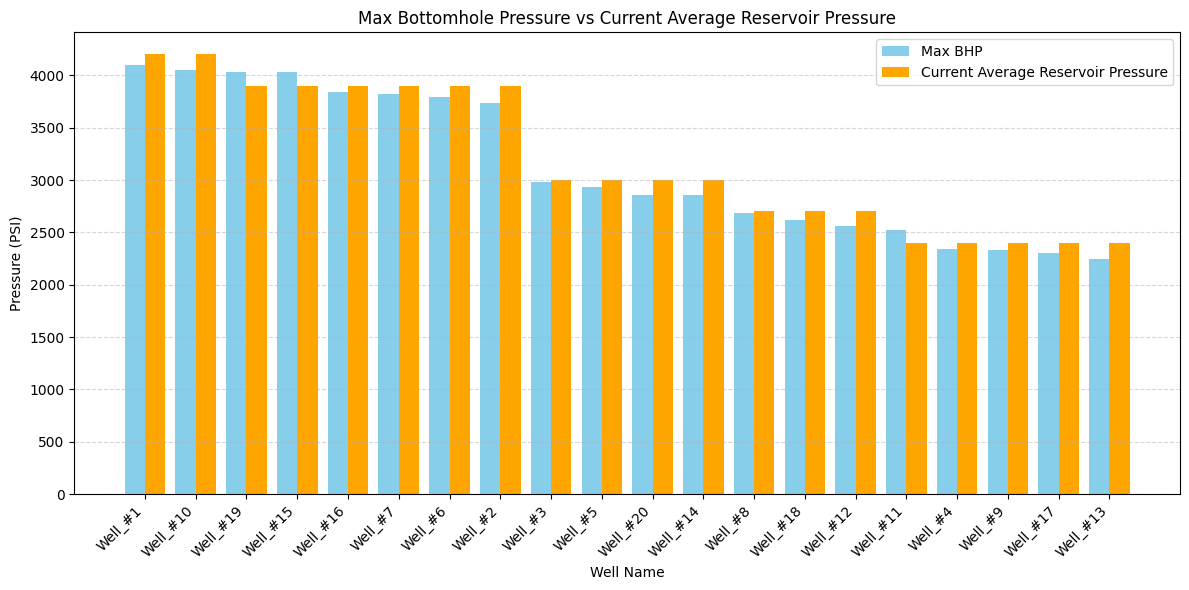

In [ ]:
merged_df = classification_df.merge(
    reservoir_info[['Reservoir Name', 'Current Average Reservoir Pressure (PSI)']],
    how='left',
    left_on='Reservoir_Name',
    right_on='Reservoir Name'
)

# Sort for cleaner plot
merged_df = merged_df.sort_values(by='Max_BHP', ascending=False)

# Plotting
plt.figure(figsize=(12, 6))
bar_width = 0.4
x = range(len(merged_df))

# Plot Max BHP
plt.bar(x, merged_df['Max_BHP'], width=bar_width, label='Max BHP', color='skyblue')

# Plot Initial Reservoir Pressure (overlay bars)
plt.bar(
    [i + bar_width for i in x],
    merged_df['Current Average Reservoir Pressure (PSI)'],
    width=bar_width,
    label='Current Average Reservoir Pressure',
    color='orange'
)

# Add well names as x-tick labels
plt.xticks([i + bar_width / 2 for i in x], merged_df['Well_Name'], rotation=45, ha='right')

# Labels and title
plt.xlabel('Well Name')
plt.ylabel('Pressure (PSI)')
plt.title('Max Bottomhole Pressure vs Current Average Reservoir Pressure')
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


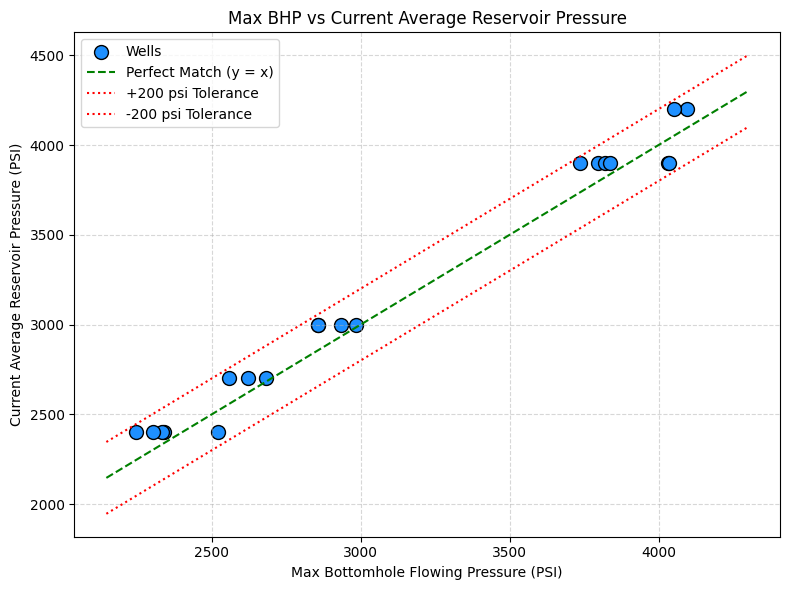

In [10]:
# Merge classification data with reservoir info
scatter_df = classification_df.merge(
    reservoir_info[['Reservoir Name', 'Current Average Reservoir Pressure (PSI)']],
    how='left',
    left_on='Reservoir_Name',
    right_on='Reservoir Name'
)

# Plot
plt.figure(figsize=(8, 6))

# Scatter points
plt.scatter(
    scatter_df['Max_BHP'],
    scatter_df['Current Average Reservoir Pressure (PSI)'],
    c='dodgerblue',
    edgecolor='black',
    s=100,
    label='Wells'
)

# Diagonal line (perfect match line)
min_val = min(scatter_df['Max_BHP'].min(), scatter_df['Current Average Reservoir Pressure (PSI)'].min()) - 100
max_val = max(scatter_df['Max_BHP'].max(), scatter_df['Current Average Reservoir Pressure (PSI)'].max()) + 100

plt.plot([min_val, max_val], [min_val, max_val], color='green', linestyle='--', label='Perfect Match (y = x)')

# Upper and lower bounds (+/- 200 psi)
plt.plot([min_val, max_val], [min_val + 200, max_val + 200], color='red', linestyle=':', label='+200 psi Tolerance')
plt.plot([min_val, max_val], [min_val - 200, max_val - 200], color='red', linestyle=':', label='-200 psi Tolerance')

# Labels and title
plt.xlabel('Max Bottomhole Flowing Pressure (PSI)')
plt.ylabel('Current Average Reservoir Pressure (PSI)')
plt.title('Max BHP vs Current Average Reservoir Pressure')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()


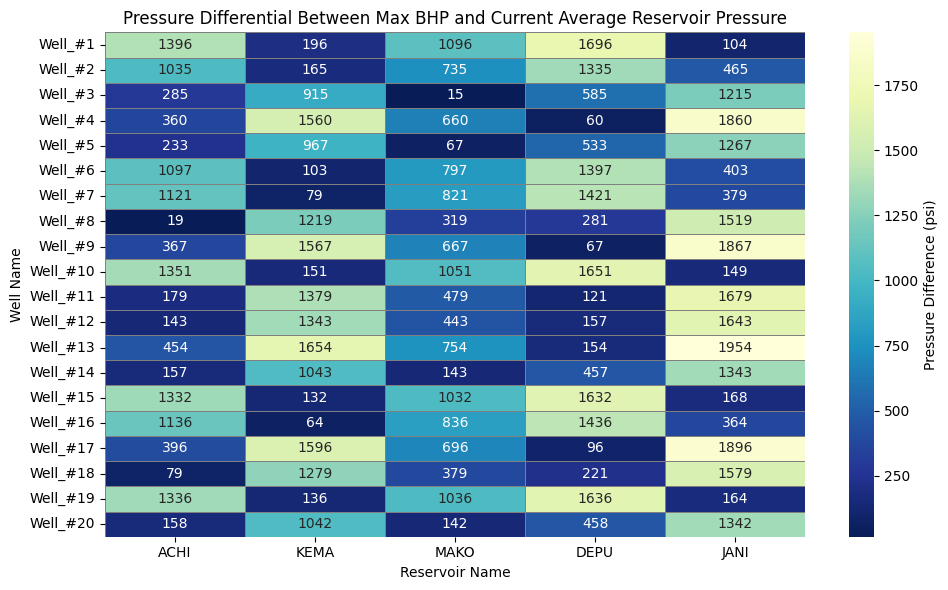

In [11]:
# Create a dictionary to store pressure differentials
pressure_diff_matrix = {}

# Loop through each well
for well in classification_df['Well_Name']:
    # Get max BHP for this well
    max_bhp = classification_df[classification_df['Well_Name'] == well]['Max_BHP'].values[0]
    
    # Calculate pressure difference for each reservoir
    diffs = {}
    for _, row in reservoir_info.iterrows():
        reservoir_name = row['Reservoir Name']
        reservoir_pressure = row['Current Average Reservoir Pressure (PSI)']
        diff = abs(max_bhp - reservoir_pressure)
        diffs[reservoir_name] = diff
    
    pressure_diff_matrix[well] = diffs

# Convert to DataFrame
pressure_diff_df = pd.DataFrame.from_dict(pressure_diff_matrix, orient='index')

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    pressure_diff_df,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu_r",  # Inverted green-blue color map: green = lower, blue = higher
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Pressure Difference (psi)'}
)

plt.title("Pressure Differential Between Max BHP and Current Average Reservoir Pressure")
plt.xlabel("Reservoir Name")
plt.ylabel("Well Name")
plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

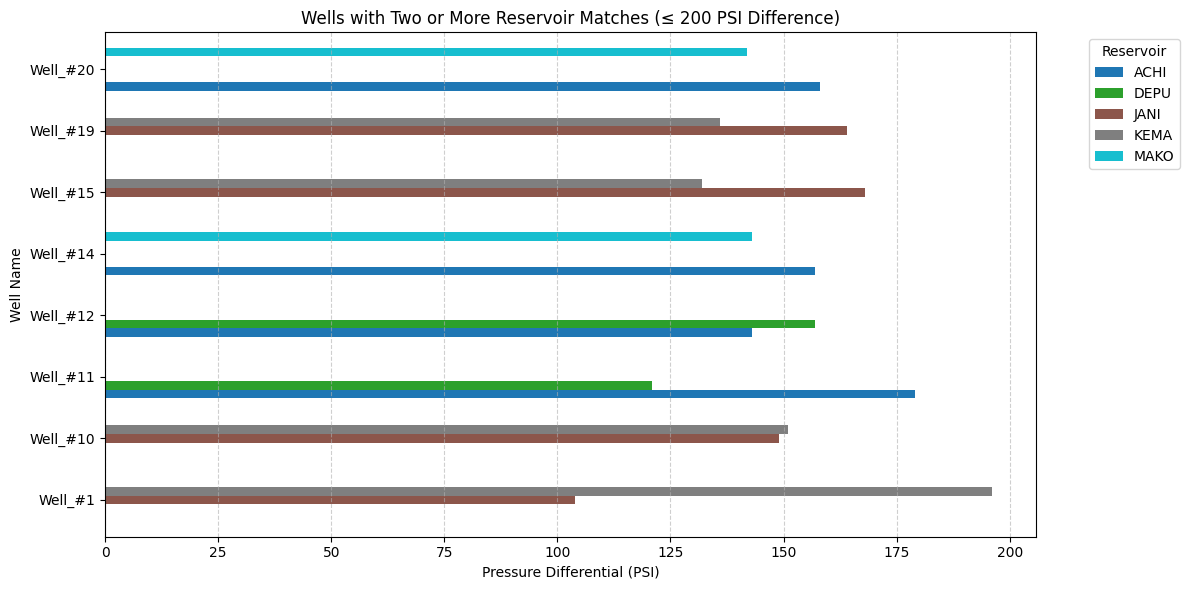

In [12]:
# Step 1: Create a list to store wells with multiple potential matches
multi_match_records = []

# Loop through each well to find multiple matches
for well in classification_df['Well_Name']:
    max_bhp = classification_df[classification_df['Well_Name'] == well]['Max_BHP'].values[0]
    
    # Loop through reservoirs and check which are within 200 psi
    matches = []
    for _, res_row in reservoir_info.iterrows():
        res_name = res_row['Reservoir Name']
        init_pressure = res_row['Current Average Reservoir Pressure (PSI)']
        diff = abs(max_bhp - init_pressure)
        
        if diff <= 200:
            matches.append((res_name, diff))
    
    # Only include wells with 2 or more matching reservoirs
    if len(matches) >= 2:
        for match in matches:
            multi_match_records.append({
                'Well_Name': well,
                'Reservoir_Name': match[0],
                'Pressure_Diff': match[1]
            })

# Convert to DataFrame
multi_match_df = pd.DataFrame(multi_match_records)

if multi_match_df.empty:
    print("No wells have two or more potential reservoirs within 200 psi.")
else:
    # Step 2: Create visualization
    plt.figure(figsize=(12, 6))

    # Pivot data for plotting
    pivot_df = multi_match_df.pivot(index='Well_Name', columns='Reservoir_Name', values='Pressure_Diff')

    # Plot as horizontal bar chart
    pivot_df.plot(kind='barh', figsize=(12, 6), colormap='tab10', width=0.7)

    plt.xlabel("Pressure Differential (PSI)")
    plt.ylabel("Well Name")
    plt.title("Wells with Two or More Reservoir Matches (≤ 200 PSI Difference)")
    plt.legend(title="Reservoir", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


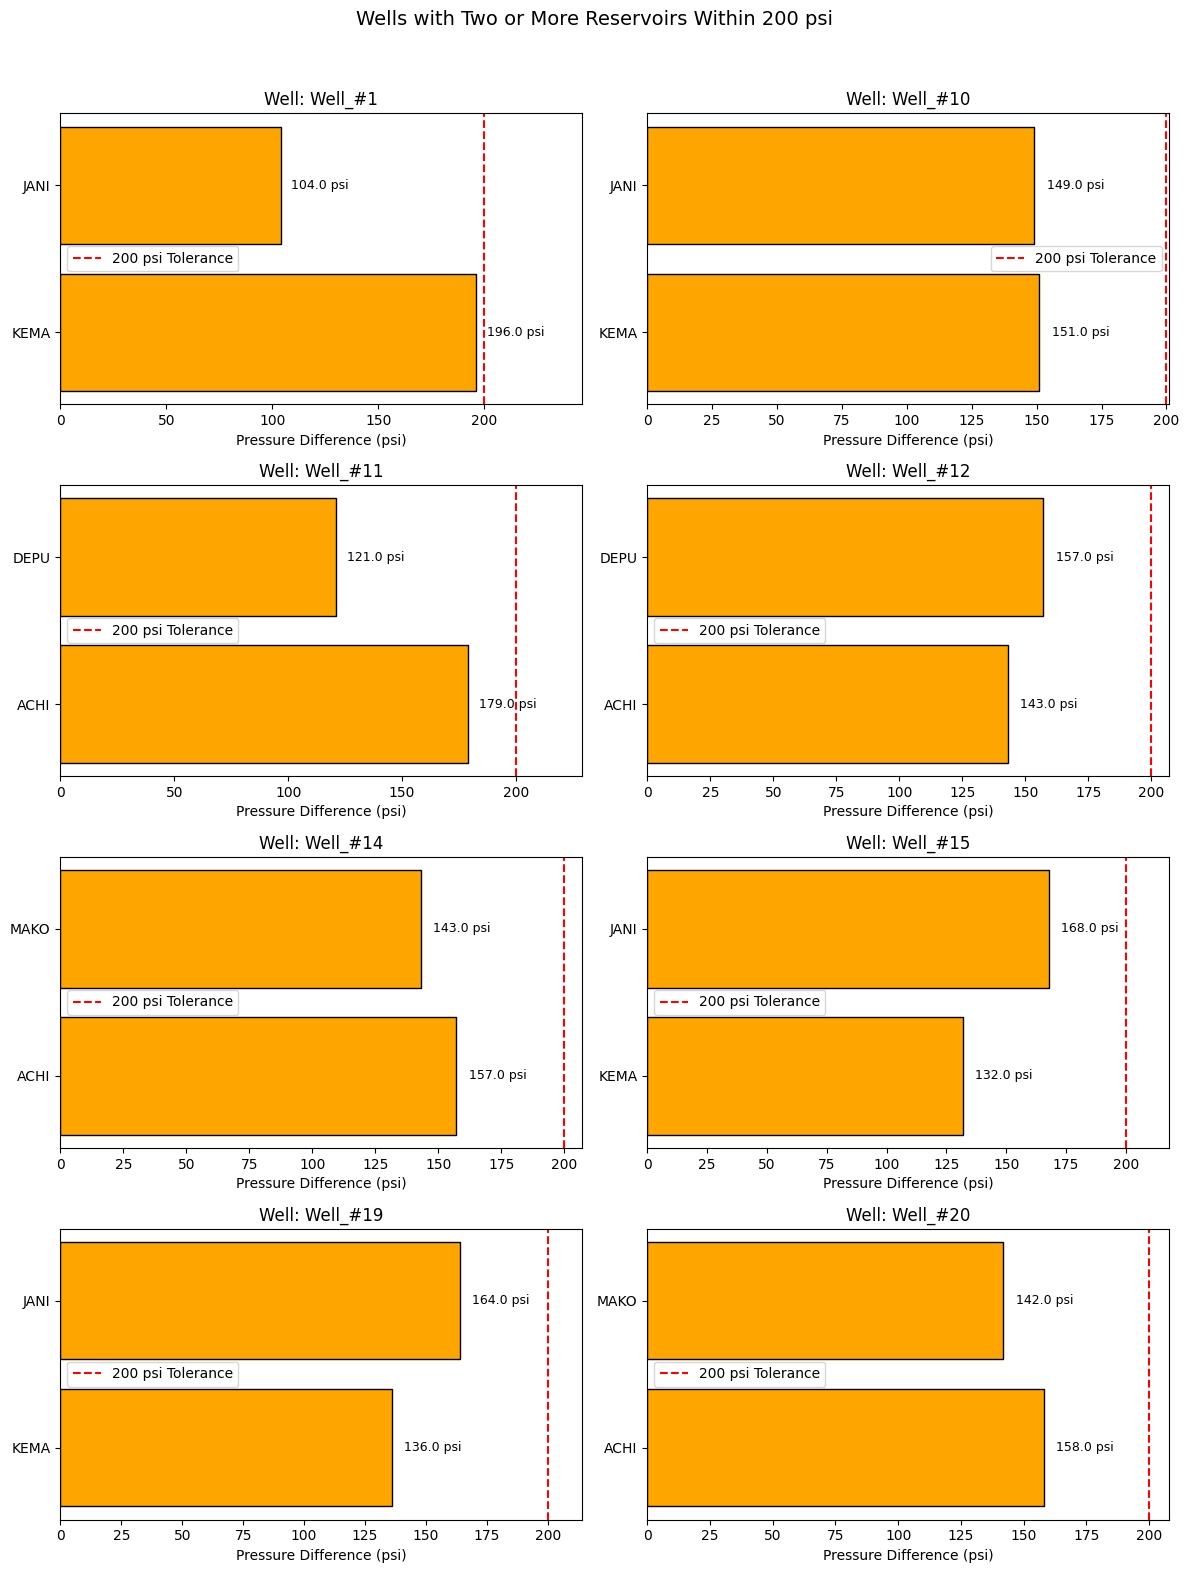

In [ ]:
import matplotlib.pyplot as plt
import math

# Threshold for pressure difference
tolerance = 200

# Store wells with multiple matches
multi_match_wells = {}

# Identify wells with 2 or more reservoir matches
for well in classification_df['Well_Name']:
    max_bhp = classification_df[classification_df['Well_Name'] == well]['Max_BHP'].values[0]
    matches = []

    for _, row in reservoir_info.iterrows():
        reservoir = row['Reservoir Name']
        init_pressure = row['Current Average Reservoir Pressure (PSI)']
        diff = abs(max_bhp - init_pressure)
        if diff <= tolerance:
            matches.append((reservoir, diff))

    if len(matches) >= 2:
        multi_match_wells[well] = matches

# Plot subplots if there are any multi-match wells
if not multi_match_wells:
    print("No wells have two or more potential reservoir matches within ±200 psi.")
else:
    num_wells = len(multi_match_wells)
    cols = 2
    rows = math.ceil(num_wells / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    axes = axes.flatten()

    for idx, (well, matches) in enumerate(multi_match_wells.items()):
        reservoirs = [m[0] for m in matches]
        diffs = [m[1] for m in matches]

        ax = axes[idx]
        bars = ax.barh(reservoirs, diffs, color='orange', edgecolor='black')

        for bar, diff in zip(bars, diffs):
            ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
                    f'{diff:.1f} psi', va='center', fontsize=9)

        ax.set_title(f'Well: {well}', fontsize=12)
        ax.set_xlabel('Pressure Difference (psi)')
        ax.axvline(x=200, color='red', linestyle='--', label='200 psi Tolerance')
        ax.set_xlim(0, max(diffs) + 50)
        ax.legend()

    # Hide any unused subplots
    for i in range(idx + 1, len(axes)):
        fig.delaxes(axes[i])
    fig.suptitle('Wells with Two or More Reservoirs Within 200 psi', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
